In [169]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download latest version
path = kagglehub.dataset_download("emirhanai/social-media-usage-and-emotional-well-being")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'social-media-usage-and-emotional-well-being' dataset.
Path to dataset files: /kaggle/input/social-media-usage-and-emotional-well-being


In [170]:
contents = os.listdir(path)
print(contents)

['val.csv', 'train.csv', 'test.csv']


In [171]:
from IPython.display import FileLink
import os # Make sure os is imported for os.path.exists and os.mkdir

# Define paths for the cleaned dataframes

folder_name = "social media usage and emotional well being dataset"

# Check if the folder does not exist before creating it
if not os.path.exists(folder_name):
    os.mkdir(folder_name)
    print(f"Folder '{folder_name}' created successfully.")
else:
    print(f"Folder '{folder_name}' already exists.")

download_path = '/content/social media usage and emotional well being dataset'

Folder 'social media usage and emotional well being dataset' already exists.


In [172]:
df1 = pd.read_csv(os.path.join(path, 'train.csv'))
df2 = pd.read_csv(os.path.join(path, 'test.csv'))
df3 = pd.read_csv(os.path.join(path, 'test.csv'))
df1.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [173]:
import os

# Ensure the download_path exists from previous cells or define it if this cell is run independently
if 'download_path' not in locals() or not os.path.exists(download_path):
    folder_name = "social media usage and emotional well being dataset"
    writable_base_dir = "/content/"
    download_path = os.path.join(writable_base_dir, folder_name)
    os.makedirs(download_path, exist_ok=True)
    print(f"Created or ensured existence of folder: {download_path}")

# Save df1, df2, and df3 to CSV files in the specified folder
df1.to_csv(os.path.join(download_path, 'train.csv'), index=False)
df2.to_csv(os.path.join(download_path, 'test.csv'), index=False)
df3.to_csv(os.path.join(download_path, 'val.csv'), index=False)

print(f"df1.csv, df2.csv, and df3.csv have been saved to '{download_path}'.")

df1.csv, df2.csv, and df3.csv have been saved to '/content/social media usage and emotional well being dataset'.


### EDA

In [174]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB


In [175]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   User_ID                     103 non-null    int64 
 1   Age                         103 non-null    object
 2   Gender                      103 non-null    object
 3   Platform                    103 non-null    object
 4   Daily_Usage_Time (minutes)  103 non-null    int64 
 5   Posts_Per_Day               103 non-null    int64 
 6   Likes_Received_Per_Day      103 non-null    int64 
 7   Comments_Received_Per_Day   103 non-null    int64 
 8   Messages_Sent_Per_Day       103 non-null    int64 
 9   Dominant_Emotion            103 non-null    object
dtypes: int64(6), object(4)
memory usage: 8.2+ KB


In [176]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   User_ID                     103 non-null    int64 
 1   Age                         103 non-null    object
 2   Gender                      103 non-null    object
 3   Platform                    103 non-null    object
 4   Daily_Usage_Time (minutes)  103 non-null    int64 
 5   Posts_Per_Day               103 non-null    int64 
 6   Likes_Received_Per_Day      103 non-null    int64 
 7   Comments_Received_Per_Day   103 non-null    int64 
 8   Messages_Sent_Per_Day       103 non-null    int64 
 9   Dominant_Emotion            103 non-null    object
dtypes: int64(6), object(4)
memory usage: 8.2+ KB


In [177]:
#combine them to EDA properly

df_train = df1.copy()
df_test = pd.concat([df2, df3], axis=0)
df_train.head()

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [178]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB


In [179]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   User_ID                     206 non-null    int64 
 1   Age                         206 non-null    object
 2   Gender                      206 non-null    object
 3   Platform                    206 non-null    object
 4   Daily_Usage_Time (minutes)  206 non-null    int64 
 5   Posts_Per_Day               206 non-null    int64 
 6   Likes_Received_Per_Day      206 non-null    int64 
 7   Comments_Received_Per_Day   206 non-null    int64 
 8   Messages_Sent_Per_Day       206 non-null    int64 
 9   Dominant_Emotion            206 non-null    object
dtypes: int64(6), object(4)
memory usage: 17.7+ KB


In [180]:
df_train.duplicated().sum()

np.int64(0)

In [181]:
df_train.drop('User_ID', axis=1, inplace=True)
df_test.drop('User_ID', axis=1, inplace=True)

In [182]:
features = df_train.columns

In [183]:
for feat in features:
  print(df_train[feat].value_counts())
  print('\n')

Age
28                                                      92
27                                                      92
29                                                      90
22                                                      74
26                                                      66
24                                                      64
25                                                      64
31                                                      62
21                                                      56
33                                                      56
30                                                      48
23                                                      48
35                                                      38
32                                                      38
34                                                      36
Male                                                    28
Female                                              

In [184]:
#check who has mixed up age and gender
df_train[df_train['Age'] == 'Male']

,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
250,Male,27,Instagram,165.0,6.0,85.0,30.0,28.0,Happiness
254,Male,31,LinkedIn,60.0,1.0,15.0,7.0,17.0,Anxiety
256,Male,25,Telegram,90.0,3.0,22.0,11.0,22.0,Boredom
259,Male,27,Facebook,60.0,1.0,12.0,5.0,15.0,Boredom
261,Male,23,Whatsapp,70.0,3.0,22.0,10.0,18.0,Anger
264,Male,25,Twitter,90.0,6.0,42.0,14.0,26.0,Sadness
266,Male,28,Instagram,165.0,5.0,78.0,23.0,35.0,Happiness
268,Male,27,Telegram,105.0,3.0,48.0,20.0,28.0,Anxiety
271,Male,35,Twitter,70.0,1.0,13.0,8.0,10.0,Boredom
274,Male,25,Telegram,80.0,4.0,30.0,13.0,25.0,Neutral


In [185]:
df_train['Gender'].value_counts()

,count
Gender,
Female,344
Male,332
Non-binary,248
29,10
27,8
31,8
28,8
24,6
25,6


In [186]:
# Make a function that swaps mixed gender and age

mask = df_train['Age'] == 'Male'
df_train.loc[mask, ['Age', 'Gender']] = df_train.loc[mask, ['Gender', 'Age']].values

mask2 = df_train['Age'] == 'Female'
df_train.loc[mask2, ['Age', 'Gender']] = df_train.loc[mask2, ['Gender', 'Age']].values

mask3 = df_train['Age'] == 'Non-binary'
df_train.loc[mask3, ['Age', 'Gender']] = df_train.loc[mask3, ['Gender', 'Age']].values

In [187]:
mask = df_test['Age'] == 'Male'
df_test.loc[mask, ['Age', 'Gender']] = df_test.loc[mask, ['Gender', 'Age']].values

mask2 = df_train['Age'] == 'Female'
df_test.loc[mask2, ['Age', 'Gender']] = df_test.loc[mask2, ['Gender', 'Age']].values

mask3 = df_test['Age'] == 'Non-binary'
df_test.loc[mask3, ['Age', 'Gender']] = df_test.loc[mask3, ['Gender', 'Age']].values

In [188]:
df_train['Age'].value_counts()

,count
Age,
28,100
27,100
29,100
22,80
24,70
26,70
31,70
25,70
21,60


In [189]:
#Remove any gender that isn't Male, Female, or Non-Binary

df_train = df_train[df_train['Gender'].isin(['Male', 'Female', 'Non-binary'])]
df_train['Gender'].value_counts()

,count
Gender,
Female,370
Male,360
Non-binary,270


In [190]:
df_test = df_test[df_test['Gender'].isin(['Male', 'Female', 'Non-binary'])]
df_test['Gender'].value_counts()

,count
Gender,
Male,94
Non-binary,60
Female,50


In [191]:
df_train_cleaned = df_train[pd.to_numeric(df_train['Age'], errors='coerce').notnull()]

df_test_cleaned = df_test[pd.to_numeric(df_train['Age'], errors='coerce').notnull()]

/tmp/ipykernel_2430/1050468772.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_test_cleaned = df_test[pd.to_numeric(df_train['Age'], errors='coerce').notnull()]


In [192]:
#convert string to integer
df_train_cleaned['Age']=df_train_cleaned['Age'].astype(str).astype(int)
df_test_cleaned['Age']=df_test_cleaned['Age'].astype(str).astype(int)

In [193]:
df_train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1000
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1000 non-null   int64  
 1   Gender                      1000 non-null   object 
 2   Platform                    1000 non-null   object 
 3   Daily_Usage_Time (minutes)  1000 non-null   float64
 4   Posts_Per_Day               1000 non-null   float64
 5   Likes_Received_Per_Day      1000 non-null   float64
 6   Comments_Received_Per_Day   1000 non-null   float64
 7   Messages_Sent_Per_Day       1000 non-null   float64
 8   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), int64(1), object(3)
memory usage: 110.4+ KB


In [194]:
#Split data menjadi train-test

# from sklearn.model_selection import train_test_split

# x = df_cleaned.drop({'Dominant_Emotion'}, axis=1)
# y = df_cleaned['Dominant_Emotion']

# x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

x_train = df_train_cleaned.drop({'Dominant_Emotion'}, axis=1)
y_train = df_train_cleaned['Dominant_Emotion']

x_test = df_test_cleaned.drop({'Dominant_Emotion'}, axis=1)
y_test = df_test_cleaned['Dominant_Emotion']

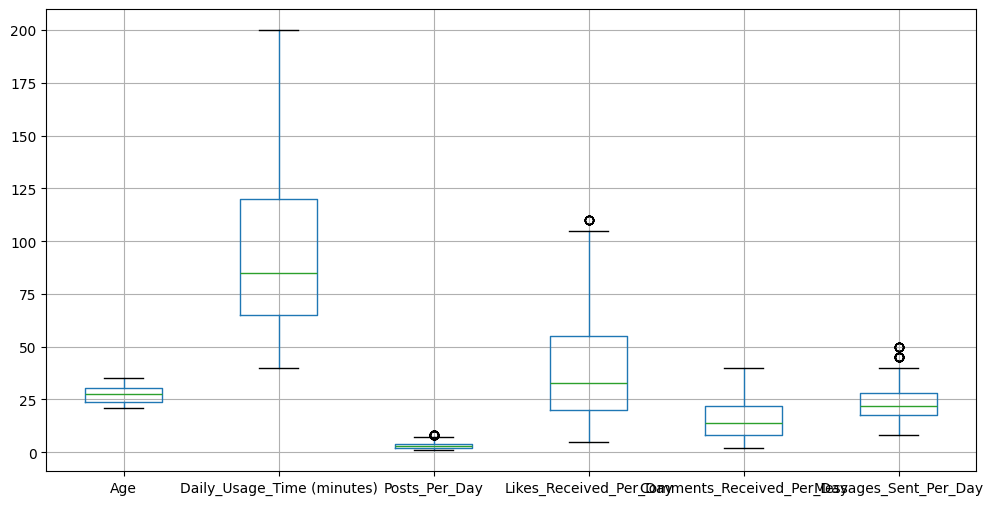

In [195]:
cat_feat = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_feat = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


plt.figure(figsize=(12,6))
boxplot = x_train.boxplot(column=num_feat)
plt.show()

In [196]:
x_train[num_feat].head()

,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,25,120.0,3.0,45.0,10.0,12.0
1,30,90.0,5.0,20.0,25.0,30.0
2,22,60.0,2.0,15.0,5.0,20.0
3,28,200.0,8.0,100.0,30.0,50.0
4,33,45.0,1.0,5.0,2.0,10.0


Data terlihat normal dan tidak ada outlier mustahil

In [197]:
print("Dominant emotion in each platforms\n")
for platform in df_train_cleaned['Platform'].unique():
  print(f'{platform}: {df_train_cleaned[df_train_cleaned['Platform'] == platform]['Dominant_Emotion'].mode().values[0]}')
  print('\n')


Dominant emotion in each platforms

Instagram: Happiness


Twitter: Anger


Facebook: Neutral


LinkedIn: Boredom


Whatsapp: Anger


Telegram: Neutral


Snapchat: Sadness




### Preprocessing & Training

Untuk Encoding:

Gender: Ordinal Encoding
Platform: One hot encoding

In [198]:
x_train[cat_feat].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 1000
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Gender    1000 non-null   object
 1   Platform  1000 non-null   object
dtypes: object(2)
memory usage: 55.7+ KB


In [199]:
#For ordinal encoding

df_encode={"Gender": {"Non-binary":2, "Male":1,"Female" :0}}
x_train=x_train.replace(df_encode)
x_test=x_test.replace(df_encode)

/tmp/ipykernel_2430/3990675678.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train=x_train.replace(df_encode)
/tmp/ipykernel_2430/3990675678.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test=x_test.replace(df_encode)


In [200]:
#For one hot encoding

from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
df_enc = pd.DataFrame(enc.fit_transform(x_train[['Platform']]).toarray(),columns=enc.get_feature_names_out())
df_enc2 = pd.DataFrame(enc.transform(x_test[['Platform']]).toarray(),columns=enc.get_feature_names_out())

x_train=x_train.reset_index()
x_test=x_test.reset_index()

x_train=pd.concat([x_train,df_enc], axis=1)
x_test=pd.concat([x_test,df_enc2], axis=1)

In [201]:
#Drop index and platform leftover
x_train.drop({"Platform", "index"}, axis=1, inplace=True)
x_test.drop({"Platform", "index"}, axis=1, inplace=True)

In [202]:
x_train.head()

,Age,Gender,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Platform_Facebook,Platform_Instagram,Platform_LinkedIn,Platform_Snapchat,Platform_Telegram,Platform_Twitter,Platform_Whatsapp
0,25,0,120.0,3.0,45.0,10.0,12.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,30,1,90.0,5.0,20.0,25.0,30.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,22,2,60.0,2.0,15.0,5.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,28,0,200.0,8.0,100.0,30.0,50.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,33,1,45.0,1.0,5.0,2.0,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [203]:
x_train.shape

(1000, 14)

In [204]:
x_test.shape

(204, 14)

Model yang digunakan adalah:
1. K-Nearest Neighbor
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. XGBoost

In [205]:
#Use standardscaler for data normalization in both training and testing features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [206]:
x_train.shape

(1000, 14)

In [207]:
x_test.shape

(204, 14)

In [208]:
y_train.shape

(1000,)

In [209]:
y_test.shape

(204,)

In [210]:
#Training and compare the model result

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

KNeighborsClassifier

In [211]:
knn_class = KNeighborsClassifier()

In [212]:
knn_class.fit(x_train, y_train)
y_predict_knn = knn_class.predict(x_test)

In [213]:
#Classification Result

from sklearn.metrics import classification_report
print('\nKNN Classification Report:\n')
print(classification_report(y_test, y_predict_knn))


KNN Classification Report:

              precision    recall  f1-score   support

       Anger       0.90      1.00      0.95        18
     Anxiety       1.00      0.95      0.98        44
     Boredom       0.94      0.94      0.94        32
   Happiness       1.00      0.93      0.96        28
     Neutral       1.00      0.96      0.98        54
     Sadness       0.88      1.00      0.93        28

    accuracy                           0.96       204
   macro avg       0.95      0.96      0.96       204
weighted avg       0.96      0.96      0.96       204



Decision Tree

In [214]:
dt_class = DecisionTreeClassifier()
dt_class.fit(x_train, y_train)
y_predict_dt = dt_class.predict(x_test)

In [215]:
#Classification Result

print('\nDecision Tree Classification Report:\n')
print(classification_report(y_test, y_predict_dt))


Decision Tree Classification Report:

              precision    recall  f1-score   support

       Anger       0.90      1.00      0.95        18
     Anxiety       0.95      0.91      0.93        44
     Boredom       0.93      0.88      0.90        32
   Happiness       0.93      1.00      0.97        28
     Neutral       0.93      0.96      0.95        54
     Sadness       0.92      0.86      0.89        28

    accuracy                           0.93       204
   macro avg       0.93      0.93      0.93       204
weighted avg       0.93      0.93      0.93       204



Random Forest Classifier

In [216]:
rf_class = RandomForestClassifier()
rf_class.fit(x_train, y_train)
y_predict_rf = rf_class.predict(x_test)

In [217]:
#Classification Result

print('\nRandom Forest Classification Report:\n')
print(classification_report(y_test, y_predict_rf))


Random Forest Classification Report:

              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00        18
     Anxiety       1.00      0.95      0.98        44
     Boredom       1.00      0.94      0.97        32
   Happiness       0.93      1.00      0.97        28
     Neutral       1.00      1.00      1.00        54
     Sadness       0.93      1.00      0.97        28

    accuracy                           0.98       204
   macro avg       0.98      0.98      0.98       204
weighted avg       0.98      0.98      0.98       204



SVM

In [218]:
svm_class = SVC()
svm_class.fit(x_train, y_train)
y_predict_svm = svm_class.predict(x_test)

In [219]:
#Classification Result

print('\nSupport Vector Machine Classification Report:\n')
print(classification_report(y_test, y_predict_svm))


Support Vector Machine Classification Report:

              precision    recall  f1-score   support

       Anger       0.67      0.89      0.76        18
     Anxiety       0.68      0.68      0.68        44
     Boredom       0.71      0.94      0.81        32
   Happiness       1.00      0.93      0.96        28
     Neutral       1.00      0.78      0.88        54
     Sadness       0.92      0.86      0.89        28

    accuracy                           0.82       204
   macro avg       0.83      0.85      0.83       204
weighted avg       0.85      0.82      0.83       204



XGB Classifier

In [220]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb = XGBClassifier()
xgb.fit(x_train, y_train_encoded)
y_predict_xgb = xgb.predict(x_test)
y_predict_xgb_decoded = le.inverse_transform(y_predict_xgb)

In [221]:
#Classification Result

print('\nXGBoost Classification Report:\n')
print(classification_report(y_test, y_predict_xgb_decoded))


XGBoost Classification Report:

              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00        18
     Anxiety       1.00      0.95      0.98        44
     Boredom       0.88      0.94      0.91        32
   Happiness       0.88      1.00      0.93        28
     Neutral       1.00      0.96      0.98        54
     Sadness       0.92      0.86      0.89        28

    accuracy                           0.95       204
   macro avg       0.95      0.95      0.95       204
weighted avg       0.95      0.95      0.95       204



### Evaluation

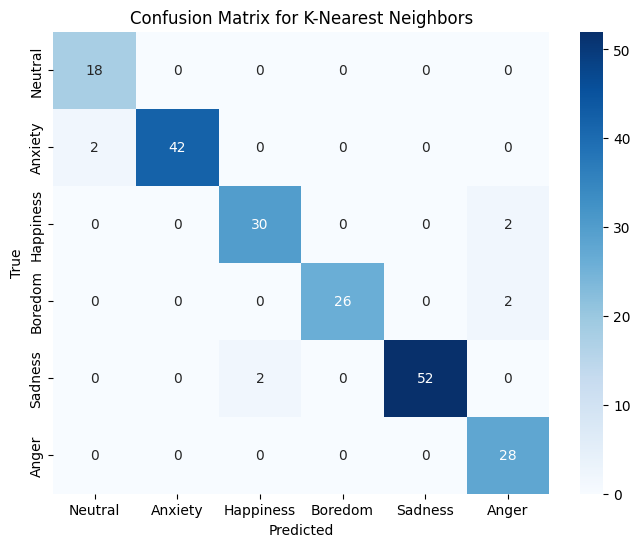

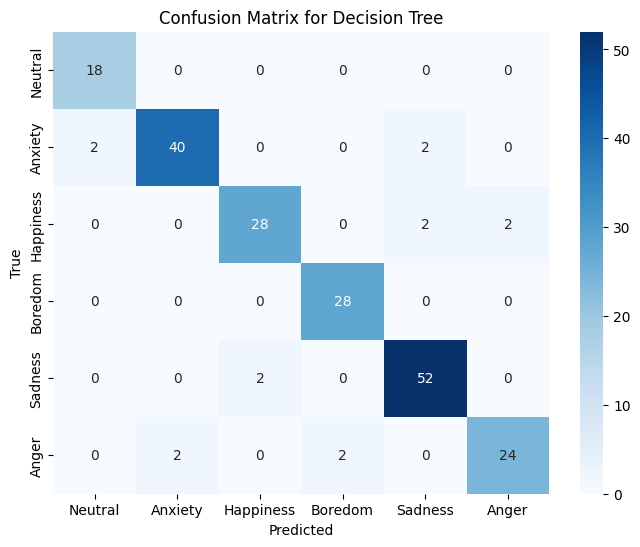

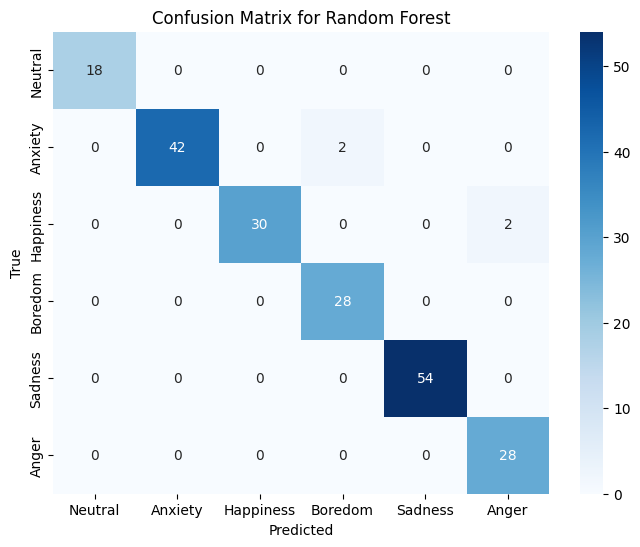

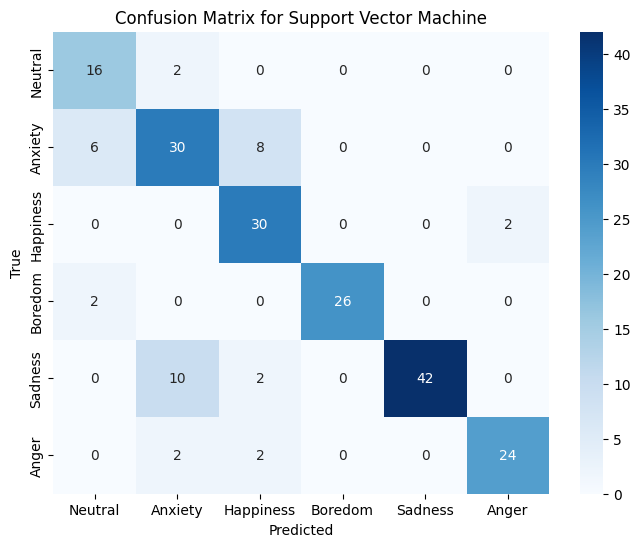

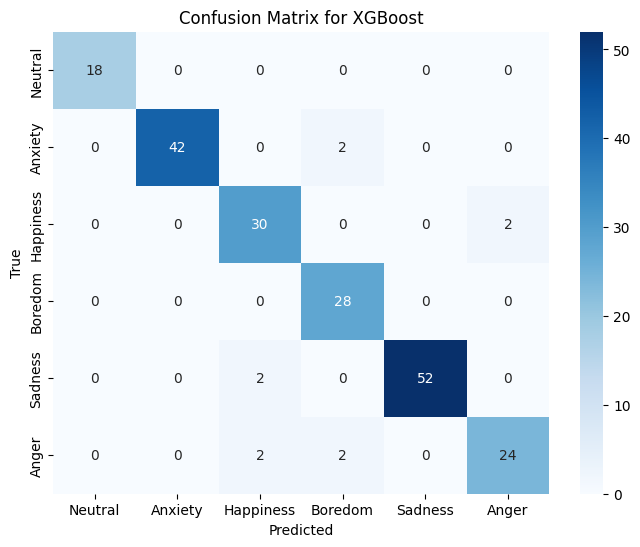

In [222]:
from sklearn.metrics import confusion_matrix

models = {
    "K-Nearest Neighbors": y_predict_knn,
    "Decision Tree": y_predict_dt,
    "Random Forest": y_predict_rf,
    "Support Vector Machine": y_predict_svm,
    "XGBoost": y_predict_xgb_decoded
}

for model_name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=y_test.unique(), yticklabels=y_test.unique())
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

/tmp/ipykernel_2430/822790722.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


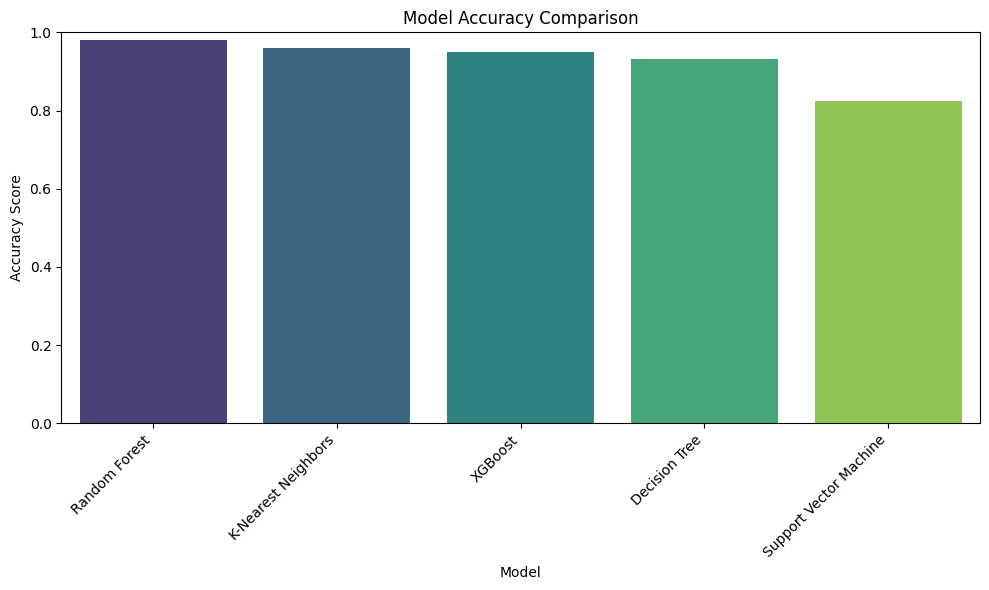

In [223]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame creation

accuracy_scores = {}

# Re-using the models dictionary defined previously
models_predictions = {
    "K-Nearest Neighbors": y_predict_knn,
    "Decision Tree": y_predict_dt,
    "Random Forest": y_predict_rf,
    "Support Vector Machine": y_predict_svm,
    "XGBoost": y_predict_xgb_decoded
}

for model_name, predictions in models_predictions.items():
    accuracy = accuracy_score(y_test, predictions)
    accuracy_scores[model_name] = accuracy

# Convert to DataFrame for easy plotting
accuracy_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [224]:
!pip install optuna

import optuna

In [225]:
#Optuna for SVM
from sklearn.model_selection import cross_val_score

def objective_svm(trial):
  #1 Suggest Hyperparameter
  C = trial.suggest_float('C', 1e-3, 1e3, log=True)
  kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
  gamma = trial.suggest_float('gamma', 1e-4, 1, log=True)

  #2 Define the model

  svm = SVC(C = C, kernel = kernel, gamma = gamma)

  #3 Evaluate model (example: Use cross validations)
  score = cross_val_score(svm, x_train, y_train, n_jobs=-1, cv=5, scoring='accuracy').mean()

  return score

In [226]:
#create study

study = optuna.create_study(direction='maximize')
study.optimize(objective_svm, n_trials=50)

[I 2026-06-08 03:52:35,131] A new study created in memory with name: no-name-62cfc36d-b40f-4dd7-8706-1a527f608b28
[I 2026-06-08 03:52:36,839] Trial 0 finished with value: 0.986 and parameters: {'C': 161.94197372131066, 'kernel': 'rbf', 'gamma': 0.11101480988813403}. Best is trial 0 with value: 0.986.
[I 2026-06-08 03:52:37,013] Trial 1 finished with value: 0.409 and parameters: {'C': 0.872666938702584, 'kernel': 'rbf', 'gamma': 0.0009780508122052473}. Best is trial 0 with value: 0.986.
[I 2026-06-08 03:52:37,085] Trial 2 finished with value: 0.9030000000000001 and parameters: {'C': 26.05569615625677, 'kernel': 'poly', 'gamma': 0.03939357624523963}. Best is trial 0 with value: 0.986.
[I 2026-06-08 03:52:37,229] Trial 3 finished with value: 0.248 and parameters: {'C': 16.695455358408584, 'kernel': 'poly', 'gamma': 0.0027749433881238497}. Best is trial 0 with value: 0.986.
[I 2026-06-08 03:52:37,381] Trial 4 finished with value: 0.7220000000000001 and parameters: {'C': 2.1629838372345045,

In [227]:
print(f"Best parameters: {study.best_params}")
print(f"Best accuracy: {study.best_value}")

Best parameters: {'C': 220.05144214762348, 'kernel': 'rbf', 'gamma': 0.9533476025532779}
Best accuracy: 0.9949999999999999


In [228]:
svm_best = SVC(C = study.best_params['C'], kernel = study.best_params['kernel'], gamma = study.best_params['gamma'])
svm_best.fit(x_train, y_train)

SVC(C=220.05144214762348, gamma=0.9533476025532779)

In [229]:
y_predict_svm_best = svm_best.predict(x_test)

In [230]:
print('\nSupport Vector Machine Best Model Classification Report:\n')
print(classification_report(y_test, y_predict_svm_best))


Support Vector Machine Best Model Classification Report:

              precision    recall  f1-score   support

       Anger       0.90      1.00      0.95        18
     Anxiety       1.00      0.95      0.98        44
     Boredom       1.00      0.88      0.93        32
   Happiness       1.00      1.00      1.00        28
     Neutral       0.96      0.96      0.96        54
     Sadness       0.88      1.00      0.93        28

    accuracy                           0.96       204
   macro avg       0.96      0.97      0.96       204
weighted avg       0.96      0.96      0.96       204



In [231]:
def objective_knn(trial):
  k = trial.suggest_int('k', 1, 10)

  distance_metrics = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'chebyshev'])

  knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metrics)

  score = cross_val_score(knn, x_train, y_train, n_jobs = -1, cv=5, scoring='accuracy').mean()

  return score

In [232]:
study = optuna.create_study(direction='maximize')
study.optimize(objective_knn, n_trials=50)

[I 2026-06-08 03:52:57,094] A new study created in memory with name: no-name-bc897605-9b48-4449-80ca-7a174ba61c3e
[I 2026-06-08 03:52:57,164] Trial 0 finished with value: 0.998 and parameters: {'k': 8, 'metric': 'manhattan'}. Best is trial 0 with value: 0.998.
[I 2026-06-08 03:52:57,208] Trial 1 finished with value: 0.9960000000000001 and parameters: {'k': 7, 'metric': 'euclidean'}. Best is trial 0 with value: 0.998.
[I 2026-06-08 03:52:57,261] Trial 2 finished with value: 0.998 and parameters: {'k': 3, 'metric': 'manhattan'}. Best is trial 0 with value: 0.998.
[I 2026-06-08 03:52:57,312] Trial 3 finished with value: 0.998 and parameters: {'k': 10, 'metric': 'manhattan'}. Best is trial 0 with value: 0.998.
[I 2026-06-08 03:52:57,354] Trial 4 finished with value: 0.994 and parameters: {'k': 1, 'metric': 'chebyshev'}. Best is trial 0 with value: 0.998.
[I 2026-06-08 03:52:57,394] Trial 5 finished with value: 0.9960000000000001 and parameters: {'k': 8, 'metric': 'euclidean'}. Best is tria

In [233]:
print(f"Best parameters: {study.best_params}")
print(f"Best accuracy: {study.best_value}")

Best parameters: {'k': 8, 'metric': 'manhattan'}
Best accuracy: 0.998


In [234]:
knn_best = KNeighborsClassifier(n_neighbors = study.best_params['k'], metric = study.best_params['metric'])

knn_best.fit(x_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=8)

In [235]:
y_predict_knn_best = knn_best.predict(x_test)

In [236]:
print('\nKNN Classifier Best Model Classification Report:\n')
print(classification_report(y_test, y_predict_knn_best))


KNN Classifier Best Model Classification Report:

              precision    recall  f1-score   support

       Anger       0.90      1.00      0.95        18
     Anxiety       0.95      0.95      0.95        44
     Boredom       0.93      0.88      0.90        32
   Happiness       1.00      0.93      0.96        28
     Neutral       1.00      0.96      0.98        54
     Sadness       0.88      1.00      0.93        28

    accuracy                           0.95       204
   macro avg       0.94      0.95      0.95       204
weighted avg       0.95      0.95      0.95       204



In [237]:
def objective_dt(trial):
    # 1 Suggest Hyperparameter for Decision Tree
    max_depth = trial.suggest_int('max_depth', 1, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    # 2 Define the model
    dt = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    # 3 Evaluate model using cross-validation
    score = cross_val_score(dt, x_train, y_train, n_jobs=-1, cv=5, scoring='accuracy').mean()

    return score

# Create a study and optimize for Decision Tree
study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=50)

[I 2026-06-08 03:52:59,568] A new study created in memory with name: no-name-5c8ea3f6-3b1c-464e-a19d-1f9ced71f491
[I 2026-06-08 03:52:59,609] Trial 0 finished with value: 0.471 and parameters: {'max_depth': 2, 'min_samples_split': 15, 'min_samples_leaf': 15, 'criterion': 'entropy'}. Best is trial 0 with value: 0.471.
[I 2026-06-08 03:52:59,640] Trial 1 finished with value: 0.882 and parameters: {'max_depth': 32, 'min_samples_split': 20, 'min_samples_leaf': 8, 'criterion': 'entropy'}. Best is trial 1 with value: 0.882.
[I 2026-06-08 03:52:59,671] Trial 2 finished with value: 0.9560000000000001 and parameters: {'max_depth': 20, 'min_samples_split': 13, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 2 with value: 0.9560000000000001.
[I 2026-06-08 03:52:59,701] Trial 3 finished with value: 0.9480000000000001 and parameters: {'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 5, 'criterion': 'entropy'}. Best is trial 2 with value: 0.9560000000000001.
[I 2026-06-08 

In [238]:
dt_best = DecisionTreeClassifier(random_state=42,
                                   max_depth=study_dt.best_params['max_depth'],
                                   min_samples_split=study_dt.best_params['min_samples_split'],
                                   min_samples_leaf=study_dt.best_params['min_samples_leaf'],
                                   criterion=study_dt.best_params['criterion'])

In [239]:
dt_best.fit(x_train, y_train)

y_predict_dt_best = dt_best.predict(x_test)

print('\nDecision Tree Best Model Classification Report:\n')
print(classification_report(y_test, y_predict_dt_best))


Decision Tree Best Model Classification Report:

              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00        18
     Anxiety       0.94      0.73      0.82        44
     Boredom       0.82      0.88      0.85        32
   Happiness       0.87      0.93      0.90        28
     Neutral       0.90      0.96      0.93        54
     Sadness       0.80      0.86      0.83        28

    accuracy                           0.88       204
   macro avg       0.89      0.89      0.89       204
weighted avg       0.89      0.88      0.88       204



In [240]:
def objective_rf(trial):
    # 1. Suggest Hyperparameters for Random Forest
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])

    # 2. Define the model
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42
    )

    # 3. Evaluate model using cross-validation
    score = cross_val_score(rf, x_train, y_train, n_jobs=-1, cv=5, scoring='accuracy').mean()

    return score

# Create a study and optimize for Random Forest
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

print(f"Best parameters for Random Forest: {study_rf.best_params}")
print(f"Best accuracy for Random Forest: {study_rf.best_value}")

[I 2026-06-08 03:53:01,581] A new study created in memory with name: no-name-cb4e1149-904d-466e-8494-c4c339713179
[I 2026-06-08 03:53:01,718] Trial 0 finished with value: 0.781 and parameters: {'n_estimators': 13, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 17, 'criterion': 'entropy'}. Best is trial 0 with value: 0.781.
[I 2026-06-08 03:53:02,816] Trial 1 finished with value: 0.778 and parameters: {'n_estimators': 169, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 19, 'criterion': 'entropy'}. Best is trial 0 with value: 0.781.
[I 2026-06-08 03:53:03,661] Trial 2 finished with value: 0.807 and parameters: {'n_estimators': 94, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 16, 'criterion': 'gini'}. Best is trial 2 with value: 0.807.
[I 2026-06-08 03:53:04,783] Trial 3 finished with value: 0.844 and parameters: {'n_estimators': 194, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 14, 'criterion': 'gini'}. Best is trial 3 with val

Best parameters for Random Forest: {'n_estimators': 10, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 2, 'criterion': 'entropy'}
Best accuracy for Random Forest: 0.9870000000000001


In [241]:
# Train the best Random Forest model
rf_best = RandomForestClassifier(random_state=42,
                                   n_estimators=study_rf.best_params['n_estimators'],
                                   max_depth=study_rf.best_params['max_depth'],
                                   min_samples_split=study_rf.best_params['min_samples_split'],
                                   min_samples_leaf=study_rf.best_params['min_samples_leaf'],
                                   criterion=study_rf.best_params['criterion'])

In [242]:
rf_best.fit(x_train, y_train)

y_predict_rf_best = rf_best.predict(x_test)

In [243]:
print('\nRandom Forest Best Model Classification Report:\n')
print(classification_report(y_test, y_predict_rf_best))


Random Forest Best Model Classification Report:

              precision    recall  f1-score   support

       Anger       0.90      1.00      0.95        18
     Anxiety       0.95      0.91      0.93        44
     Boredom       0.94      0.94      0.94        32
   Happiness       0.87      0.93      0.90        28
     Neutral       1.00      1.00      1.00        54
     Sadness       0.92      0.86      0.89        28

    accuracy                           0.94       204
   macro avg       0.93      0.94      0.93       204
weighted avg       0.94      0.94      0.94       204



In [244]:
from sklearn.model_selection import cross_val_score
import optuna
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Ensure y_train and y_test are encoded for XGBoost if not already
# (Assuming y_train_encoded and y_test_encoded are available from cell Lb7G9VzrgSY-)
# If not, the following lines would be needed:
# le = LabelEncoder()
# y_train_encoded = le.fit_transform(y_train)
# y_test_encoded = le.transform(y_test)

def objective_xgb(trial):
    # 1. Suggest Hyperparameters for XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'random_state': 42,
        'use_label_encoder': False, # Suppress warning
        'eval_metric': 'mlogloss' # For multi-class classification
    }

    # 2. Define the model
    xgb = XGBClassifier(**param)

    # 3. Evaluate model using cross-validation
    score = cross_val_score(xgb, x_train, y_train_encoded, n_jobs=-1, cv=5, scoring='accuracy').mean()

    return score

# Create a study and optimize for XGBoost
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Best parameters for XGBoost: {study_xgb.best_params}")
print(f"Best accuracy for XGBoost: {study_xgb.best_value}")

[I 2026-06-08 03:53:30,676] A new study created in memory with name: no-name-e5e7ee11-7d74-4915-8730-7ceb84125a42
[I 2026-06-08 03:53:31,622] Trial 0 finished with value: 0.9730000000000001 and parameters: {'n_estimators': 424, 'max_depth': 6, 'learning_rate': 0.21568563632226104, 'subsample': 0.5412182199821425, 'colsample_bytree': 0.8575380458856579, 'gamma': 0.47466060574605584}. Best is trial 0 with value: 0.9730000000000001.
[I 2026-06-08 03:53:32,014] Trial 1 finished with value: 0.975 and parameters: {'n_estimators': 170, 'max_depth': 10, 'learning_rate': 0.2750726786863479, 'subsample': 0.9341942109178334, 'colsample_bytree': 0.6858666156860902, 'gamma': 0.3500760996849025}. Best is trial 1 with value: 0.975.
[I 2026-06-08 03:53:32,722] Trial 2 finished with value: 0.976 and parameters: {'n_estimators': 308, 'max_depth': 4, 'learning_rate': 0.2968757205882134, 'subsample': 0.5546980725646795, 'colsample_bytree': 0.7031914969352786, 'gamma': 0.16711946315244863}. Best is trial 2

Best parameters for XGBoost: {'n_estimators': 50, 'max_depth': 10, 'learning_rate': 0.06681591658732046, 'subsample': 0.7340310041219665, 'colsample_bytree': 0.5621164979232791, 'gamma': 0.363146357292497}
Best accuracy for XGBoost: 0.991


In [245]:
# Train the best XGBoost model
xgb_best = XGBClassifier(random_state=42,
                         n_estimators=study_xgb.best_params['n_estimators'],
                         max_depth=study_xgb.best_params['max_depth'],
                         learning_rate=study_xgb.best_params['learning_rate'],
                         subsample=study_xgb.best_params['subsample'],
                         colsample_bytree=study_xgb.best_params['colsample_bytree'],
                         gamma=study_xgb.best_params['gamma'],
                         use_label_encoder=False,
                         eval_metric='mlogloss')
xgb_best.fit(x_train, y_train_encoded)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:54:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5621164979232791, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.363146357292497, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.06681591658732046,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [246]:
y_predict_xgb_best_encoded = xgb_best.predict(x_test)
y_predict_xgb_best = le.inverse_transform(y_predict_xgb_best_encoded)

In [247]:
print('\nXGBoost Best Model Classification Report:\n')
print(classification_report(y_test, y_predict_xgb_best))


XGBoost Best Model Classification Report:

              precision    recall  f1-score   support

       Anger       1.00      1.00      1.00        18
     Anxiety       1.00      0.95      0.98        44
     Boredom       0.94      0.94      0.94        32
   Happiness       0.93      1.00      0.97        28
     Neutral       1.00      0.96      0.98        54
     Sadness       0.93      1.00      0.97        28

    accuracy                           0.97       204
   macro avg       0.97      0.98      0.97       204
weighted avg       0.97      0.97      0.97       204



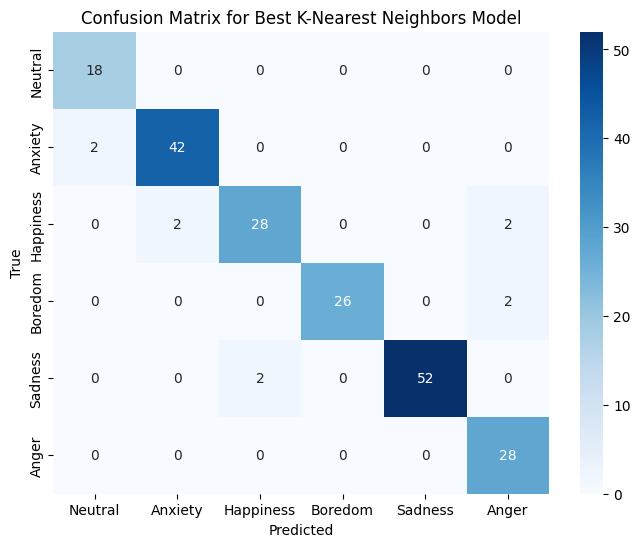

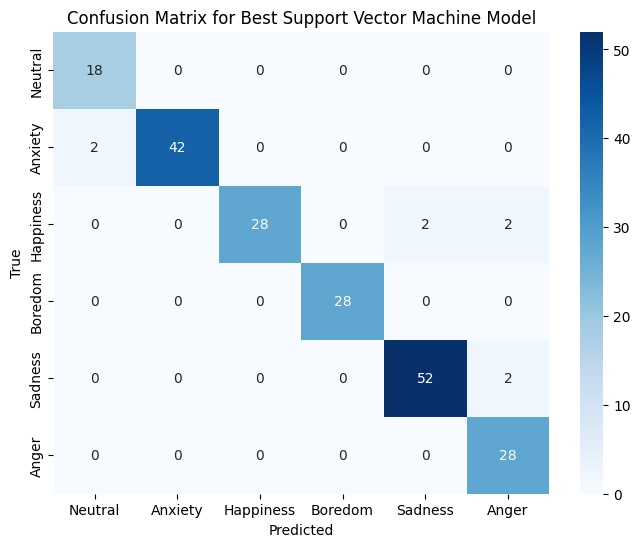

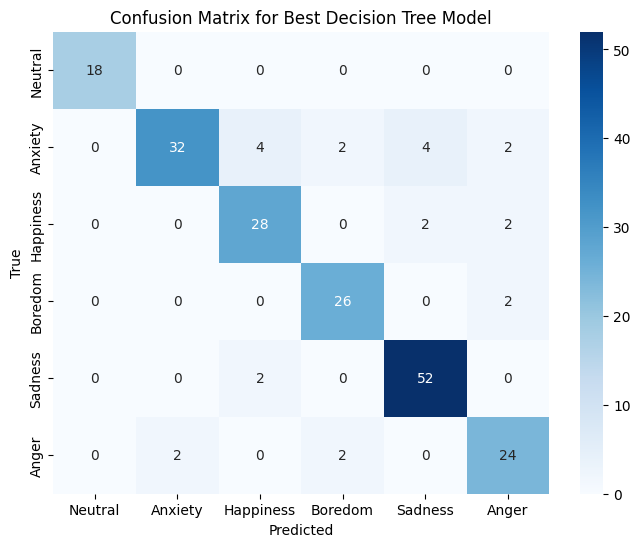

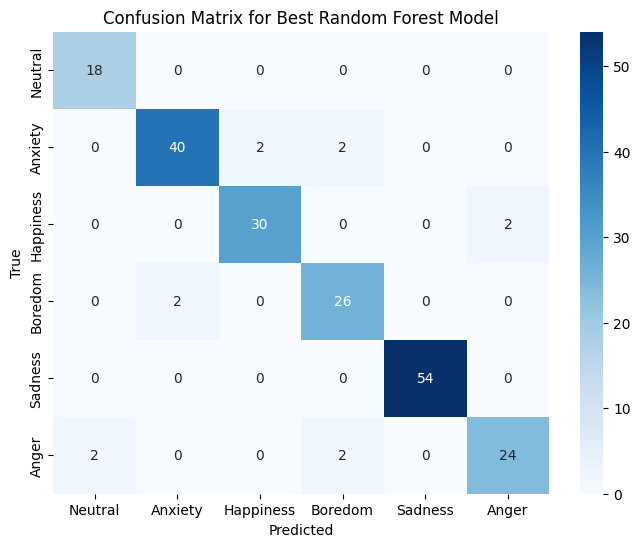

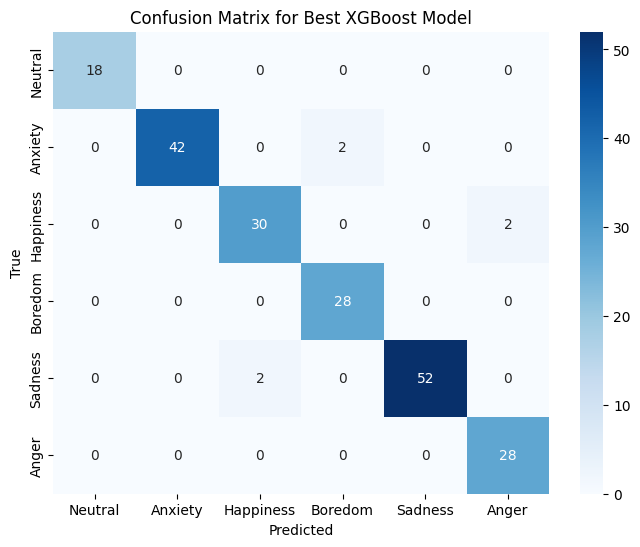

In [248]:
from sklearn.metrics import confusion_matrix

best_models = {
    "Best K-Nearest Neighbors Model": y_predict_knn_best,
    "Best Support Vector Machine Model": y_predict_svm_best,
    "Best Decision Tree Model": y_predict_dt_best,
    "Best Random Forest Model": y_predict_rf_best,
    "Best XGBoost Model": y_predict_xgb_best
}

for model_name, predictions in best_models.items():
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=y_test.unique(), yticklabels=y_test.unique())
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

/tmp/ipykernel_2430/1450097369.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


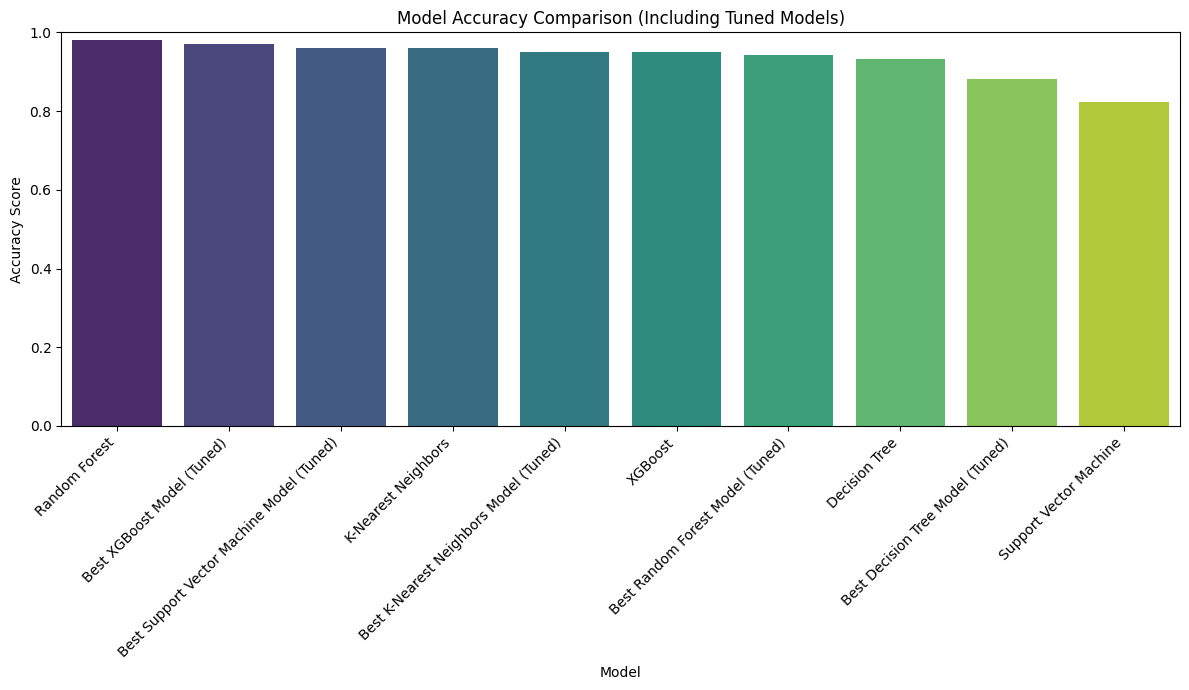

In [249]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame creation

accuracy_scores = {}

# Re-using the models dictionary defined previously
models_predictions = {
    "K-Nearest Neighbors": y_predict_knn,
    "Decision Tree": y_predict_dt,
    "Random Forest": y_predict_rf,
    "Support Vector Machine": y_predict_svm,
    "XGBoost": y_predict_xgb_decoded,
    "Best K-Nearest Neighbors Model (Tuned)": y_predict_knn_best,
    "Best Decision Tree Model (Tuned)": y_predict_dt_best,
    "Best Support Vector Machine Model (Tuned)": y_predict_svm_best,
    "Best Random Forest Model (Tuned)": y_predict_rf_best,
    "Best XGBoost Model (Tuned)": y_predict_xgb_best
}

for model_name, predictions in models_predictions.items():
    accuracy = accuracy_score(y_test, predictions)
    accuracy_scores[model_name] = accuracy

# Convert to DataFrame for easy plotting
accuracy_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy Comparison (Including Tuned Models)')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2430/494551783.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train_df_for_features = x_train_df_for_features.replace(df_encode_gender_for_features)


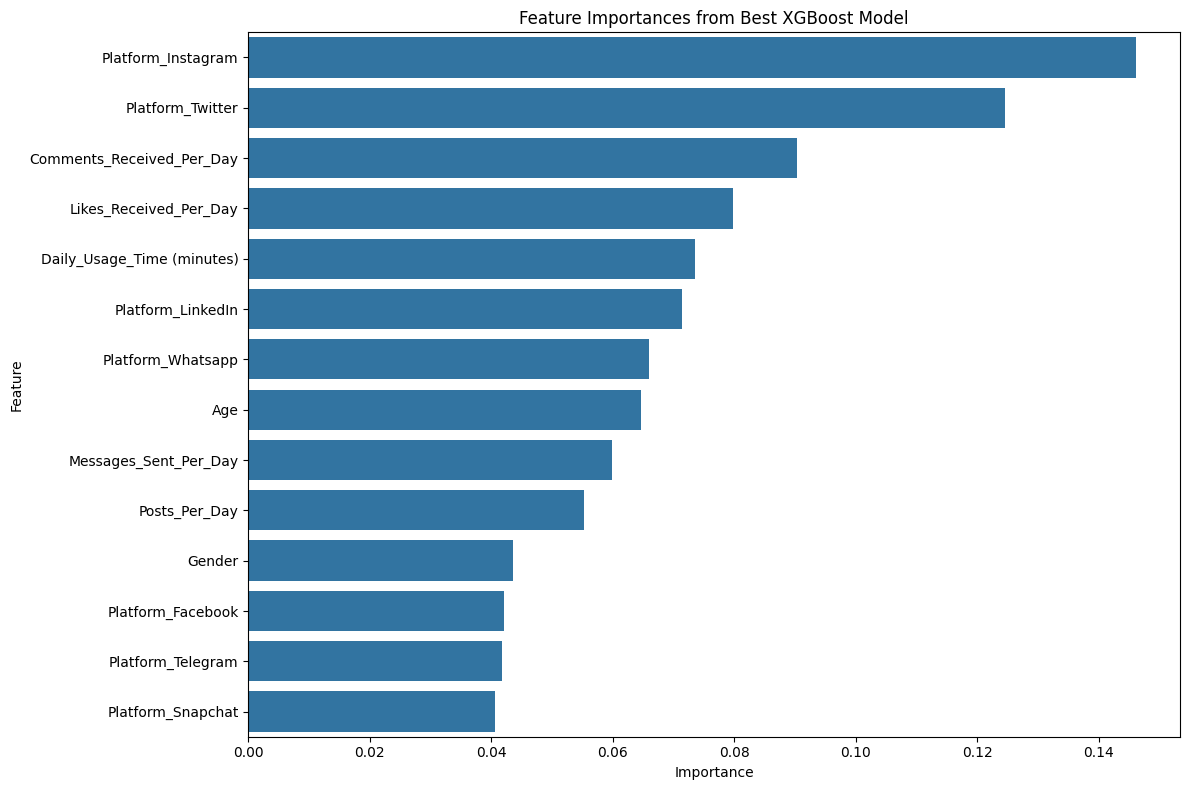


Top 10 features by importance:
                       Feature  Importance
8           Platform_Instagram    0.146103
12            Platform_Twitter    0.124632
5    Comments_Received_Per_Day    0.090420
4       Likes_Received_Per_Day    0.079808
2   Daily_Usage_Time (minutes)    0.073616
9            Platform_LinkedIn    0.071431
13           Platform_Whatsapp    0.065946
0                          Age    0.064739
6        Messages_Sent_Per_Day    0.059916
3                Posts_Per_Day    0.055197


In [251]:
# Reconstruct x_train_df for feature names to match the model's training features
# The x_train used for model training now does not include an 'index' column.
x_train_df_for_features = df_train_cleaned.drop({'Dominant_Emotion'}, axis=1).copy()

# Apply ordinal encoding to Gender
df_encode_gender_for_features = {"Gender": {"Non-binary":2, "Male":1,"Female" :0}}
x_train_df_for_features = x_train_df_for_features.replace(df_encode_gender_for_features)

# Apply one-hot encoding to Platform
enc_for_features = OneHotEncoder()
df_enc_platform_for_features = pd.DataFrame(enc_for_features.fit_transform(x_train_df_for_features[['Platform']]).toarray(),
                               columns=enc_for_features.get_feature_names_out(['Platform']))

# Drop the original index to align with the features used for model training
x_train_df_for_features = x_train_df_for_features.reset_index(drop=True)

x_train_df_for_features = pd.concat([x_train_df_for_features, df_enc_platform_for_features], axis=1)
x_train_df_for_features.drop("Platform", axis=1, inplace=True)

feature_names = x_train_df_for_features.columns

# Get feature importances from the best XGBoost model
importance = xgb_best.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from Best XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
print(feature_importance_df.head(10))

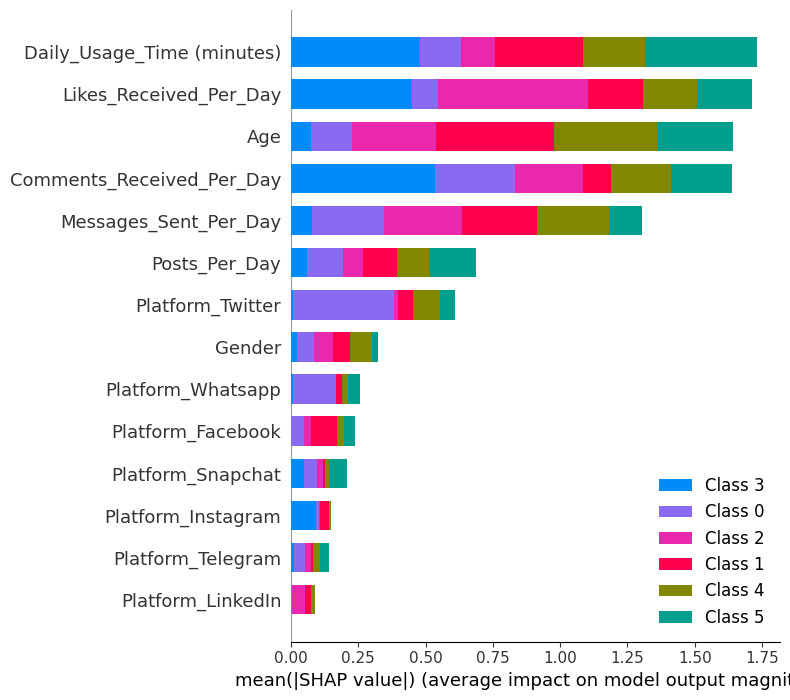

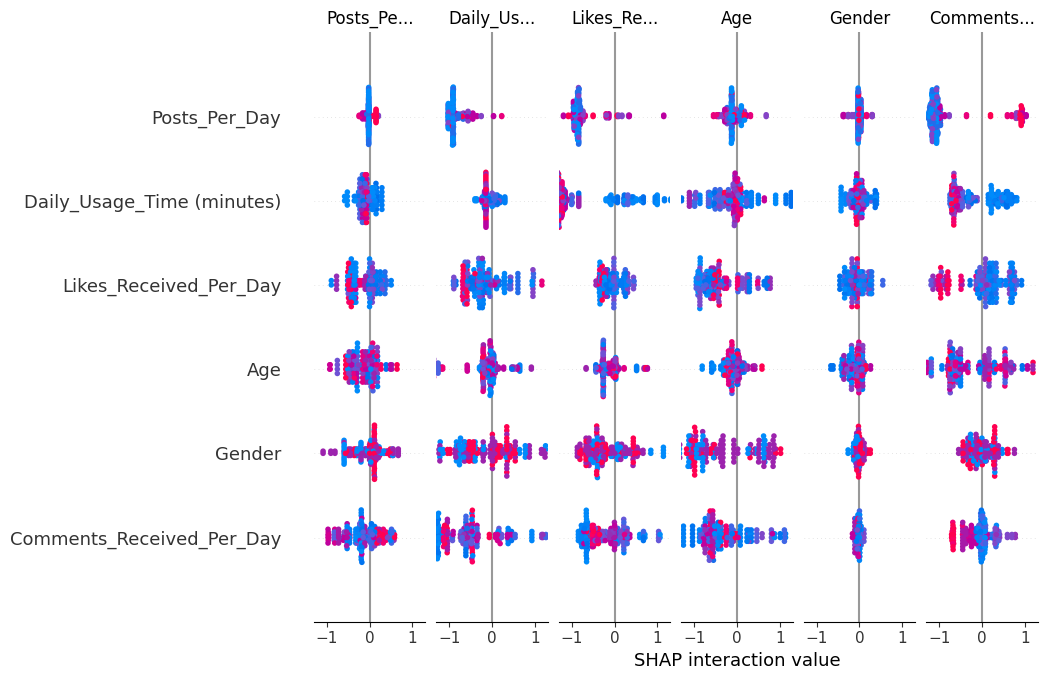

In [252]:
import shap

# Create an explainer object
explainer = shap.TreeExplainer(xgb_best)

# Calculate SHAP values for the test set
# x_test here is the scaled numpy array with 15 features (including 'index')
shap_values = explainer.shap_values(x_test)

# Summary Plot: Overall feature importance (aggregates across classes)
shap.summary_plot(shap_values, x_test, plot_type="bar", feature_names=feature_names)

# Summary Plot: Individual impact and direction (often defaults to first class for multi-class)
shap.summary_plot(shap_values, x_test, feature_names=feature_names)